In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict # Thêm cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
# Cấu hình thẩm mỹ cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

In [2]:
# =================================================================
# BƯỚC 1: NHẬP DỮ LIỆU & MÔ TẢ THỐNG KÊ
# =================================================================
# region Bước 1 - Nhập dữ liệu
# Trong notebook, __file__ không tồn tại -> dùng thư mục hiện tại.
base_dir = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()

# Ưu tiên thư mục 450 Region ngay trong base_dir; nếu không có thì dò trong thư mục con.
data_dir = base_dir / "450 Region"
if not data_dir.exists():
    candidates = list(base_dir.rglob("450 Region"))
    if candidates:
        data_dir = candidates[0]

tmd_path = data_dir / "TMD.csv"
info_path = data_dir / "HNG.xlsx"

if not tmd_path.exists() or not info_path.exists():
    raise FileNotFoundError(
        f"Không tìm thấy dữ liệu.\n"
        f"TMD: {tmd_path}\n"
        f"INFO: {info_path}\n"
        f"Hãy đặt thư mục làm việc tại nơi chứa dữ liệu hoặc giữ đúng cấu trúc thư mục."
    )

tmd_df = pd.read_csv(tmd_path)
info_df = pd.read_excel(info_path, sheet_name='QC V1')
info_df.columns = info_df.columns.str.strip()

data = pd.merge(info_df, tmd_df, on='SampleID')

print("--- [BƯỚC 1: MÔ TẢ TẬP MẪU] ---")
print(data.groupby(['Cohort', 'Label']).size().unstack(fill_value=0))
print(f"\nCấu trúc: {data.shape[0]} mẫu, {tmd_df.shape[1]-1} đặc trưng TMD.")
# endregion

--- [BƯỚC 1: MÔ TẢ TẬP MẪU] ---
Label       0.0  1.0
Cohort              
Discovery   110  110
Validation   10   31

Cấu trúc: 279 mẫu, 448 đặc trưng TMD.


In [3]:
# =================================================================
# BƯỚC 2: TÁCH DỮ LIỆU & TIỀN XỬ LÝ
# =================================================================
# region Bước 2 - Tách dữ liệu và tiền xử lý
train_df = data[data['Cohort'] == 'Discovery'].copy()
test_df = data[data['Cohort'] == 'Validation'].copy()

features = [c for c in tmd_df.columns if c != 'SampleID']

X_train_raw = train_df[features].select_dtypes(include=[np.number])
y_train = train_df['Label']

X_test_raw = test_df[features].select_dtypes(include=[np.number])
y_test = test_df['Label']

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train_raw))
X_test_scaled = scaler.transform(imputer.transform(X_test_raw))
# endregion


--- [BƯỚC 2: KHẢO SÁT PCA & LDA] ---


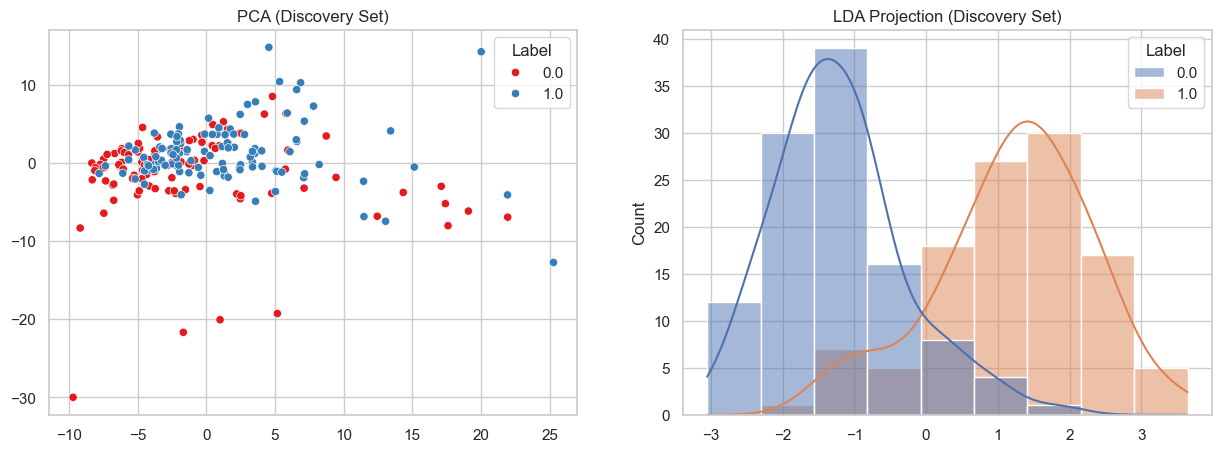

In [4]:
# =================================================================
# BƯỚC 3: KHẢO SÁT PCA & LDA
# =================================================================
# region Bước 3 - Khảo sát PCA và LDA
print("\n--- [BƯỚC 2: KHẢO SÁT PCA & LDA] ---")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_train_scaled, y_train)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train, palette='Set1', ax=ax[0])
ax[0].set_title('PCA (Discovery Set)')

sns.histplot(x=X_lda.ravel(), hue=y_train, kde=True, ax=ax[1])
ax[1].set_title('LDA Projection (Discovery Set)')
plt.show()
# endregion

In [28]:
# =================================================================
# BƯỚC 4: TUNING (10-FOLD CV)
# =================================================================
# region Bước 4 - Tuning mô hình
print("\n--- [BƯỚC 3: TUNING MODEL] ---")
param_grid = {'C': np.logspace(-4, 1, 15), 'penalty': ['l1'], 'solver': ['liblinear']}
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=2000),
    param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_
# endregion


--- [BƯỚC 3: TUNING MODEL] ---


c:\Users\pc-008\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\pc-008\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


c:\Users\pc-008\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\pc-008\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\pc-008\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penal


KẾT QUẢ AUC (CV-Adjusted):
- Discovery (10-Fold CV) AUC: 0.6700
- Validation AUC:             0.5258
- Số đặc trưng được chọn (Lasso): 150


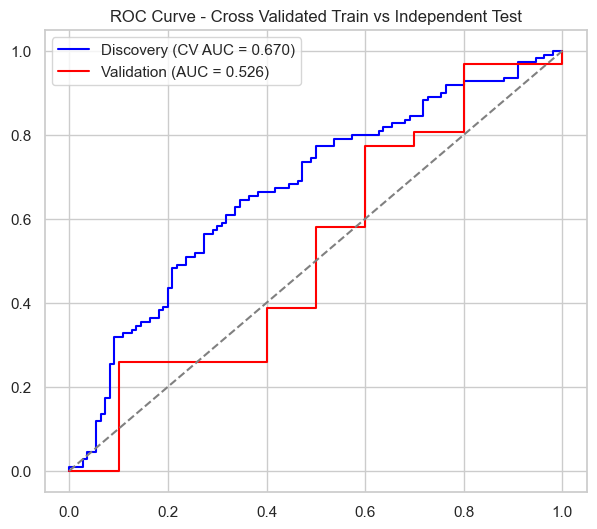

In [ ]:
# =================================================================
# BƯỚC 5: HIỂN THỊ KẾT QUẢ AUC (SỬ DỤNG CROSS-VALIDATION CHO TRAIN)
# =================================================================
# region Bước 5 - Đánh giá và trực quan hóa
y_prob_train_cv = cross_val_predict(
    best_model, X_train_scaled, y_train, 
    cv=cv_strategy, method='predict_proba'
)[:, 1]

auc_train_cv = roc_auc_score(y_train, y_prob_train_cv)
fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train_cv)

# Dự báo trên tập Validation (giữ nguyên vì đây là dữ liệu hoàn toàn mới)
y_prob_test = best_model.predict_proba(X_test_scaled)[:, 1]
auc_test = roc_auc_score(y_test, y_prob_test)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)

print("\n" + "="*50)
print(f"KẾT QUẢ AUC (CV-Adjusted):")
print(f"- Discovery (10-Fold CV) AUC: {auc_train_cv:.4f}")
print(f"- Validation AUC:             {auc_test:.4f}")
print(f"- Số đặc trưng được chọn (Lasso): {np.sum(best_model.coef_ != 0)}")
print("="*50)
# In ra giá trị C tốt nhất
print(f"Giá trị C tốt nhất: {grid_search.best_params_['C']}")

# Vẽ ROC so sánh
plt.figure(figsize=(7, 6))
plt.plot(fpr_train, tpr_train, label=f'Discovery (CV AUC = {auc_train_cv:.3f})', color='blue')
plt.plot(fpr_test, tpr_test, label=f'Validation (AUC = {auc_test:.3f})', color='red')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - Cross Validated Train vs Independent Test')
plt.legend()
plt.show()


# Confusion Matrix trên tập Validation


--- [RANDOM FOREST: TUNING MODEL - OPTIMIZED] ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits

KẾT QUẢ AUC (Random Forest Optimized):
- Best params: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 500}
- Discovery (5-Fold CV) AUC: 0.7290
- Validation AUC:             0.6710


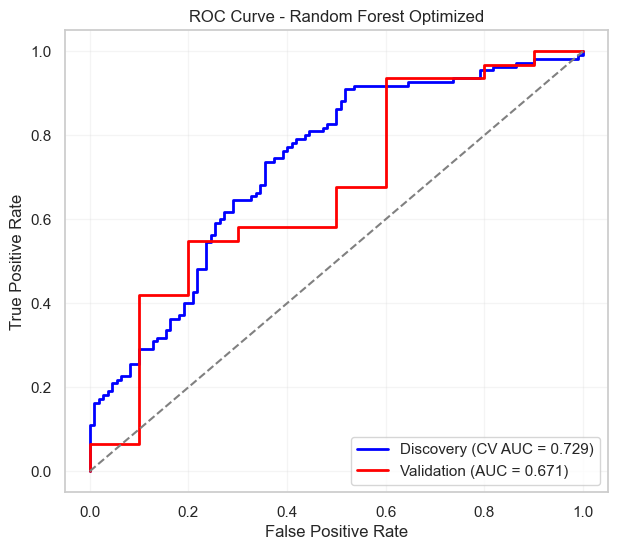


--- [RANDOM FOREST: VALIDATION REPORT @ threshold=0.5] ---
              precision    recall  f1-score   support

         0.0     0.3333    0.5000    0.4000        10
         1.0     0.8077    0.6774    0.7368        31

    accuracy                         0.6341        41
   macro avg     0.5705    0.5887    0.5684        41
weighted avg     0.6920    0.6341    0.6547        41



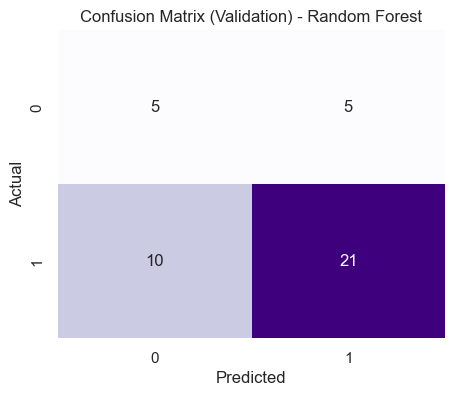

In [ ]:
# =================================================================
# PHỤ LỤC: THỬ NGHIỆM RANDOM FOREST (ĐÃ TỐI ƯU HÓA TỐC ĐỘ & BIAS)
# =================================================================
# region Random Forest Optimized
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

# 1. Kiểm tra biến đầu vào
required_vars = ["X_train_scaled", "y_train", "X_test_scaled", "y_test"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Chưa có các biến: {', '.join(missing)}. Hãy chạy các bước trước.")

# 2. Rút gọn CV xuống 5-fold để chạy nhanh và ổn định hơn
cv_strategy_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n--- [RANDOM FOREST: TUNING MODEL - OPTIMIZED] ---")

# 3. Lưới tham số tinh gọn (Tập trung vào kiểm soát độ phức tạp của cây)
# Tổng cộng: 1 (n_est) * 3 (depth) * 2 (split) * 2 (leaf) * 1 (feat) = 12 tổ hợp
rf_param_grid = {
    "n_estimators": [500],               # Số lượng cây đủ lớn để ổn định
    "max_depth": [5, 8, 12],             # Tránh để None vì dễ gây overfitting
    "min_samples_split": [5, 10],        # Tăng số mẫu tối thiểu để chia nhánh
    "min_samples_leaf": [2, 4],          # Đảm bảo mỗi lá có đủ mẫu để mang tính đại diện
    "max_features": ["sqrt"],            # Lấy căn bậc hai số lượng biến là tiêu chuẩn vàng của RF
}

# 4. Thiết lập GridSearchCV
rf_grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight="balanced",         # Tự động cân bằng trọng số lớp 0 và 1
        n_jobs=-1,                       # Chạy song song tối đa CPU
    ),
    rf_param_grid,
    cv=cv_strategy_rf,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# 5. Huấn luyện
rf_grid_search.fit(X_train_scaled, y_train)
rf_best_model = rf_grid_search.best_estimator_

# 6. Đánh giá AUC (Cross-Validation & Independent Validation)
rf_y_prob_train_cv = cross_val_predict(
    rf_best_model, X_train_scaled, y_train, 
    cv=cv_strategy_rf, method="predict_proba"
)[:, 1]

rf_y_prob_test = rf_best_model.predict_proba(X_test_scaled)[:, 1]

rf_auc_train_cv = roc_auc_score(y_train, rf_y_prob_train_cv)
rf_fpr_train, rf_tpr_train, _ = roc_curve(y_train, rf_y_prob_train_cv)

rf_auc_test = roc_auc_score(y_test, rf_y_prob_test)
rf_fpr_test, rf_tpr_test, _ = roc_curve(y_test, rf_y_prob_test)

# 7. In kết quả chi tiết
print("\n" + "=" * 60)
print("KẾT QUẢ AUC (Random Forest Optimized):")
print(f"- Best params: {rf_grid_search.best_params_}")
print(f"- Discovery (5-Fold CV) AUC: {rf_auc_train_cv:.4f}")
print(f"- Validation AUC:             {rf_auc_test:.4f}")
print("=" * 60)

# 8. Vẽ biểu đồ ROC
plt.figure(figsize=(7, 6))
plt.plot(rf_fpr_train, rf_tpr_train, label=f"Discovery (CV AUC = {rf_auc_train_cv:.3f})", color="blue", lw=2)
plt.plot(rf_fpr_test, rf_tpr_test, label=f"Validation (AUC = {rf_auc_test:.3f})", color="red", lw=2)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.title("ROC Curve - Random Forest Optimized")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

# 9. Confusion matrix + Classification report
rf_y_pred_test = (rf_y_prob_test >= 0.5).astype(int)
print("\n--- [RANDOM FOREST: VALIDATION REPORT @ threshold=0.5] ---")
print(classification_report(y_test, rf_y_pred_test, digits=4))

rf_cm = confusion_matrix(y_test, rf_y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title("Confusion Matrix (Validation) - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# endregion


--- [RANDOM FOREST: TUNING FOR STABILITY & EVALUATION] ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits

KẾT QUẢ AUC (Random Forest Robust):
- Best params: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 15, 'n_estimators': 500}
- Discovery (CV) AUC: 0.7293
- Validation AUC:     0.6677
- Gap (Train-Test):   0.0616


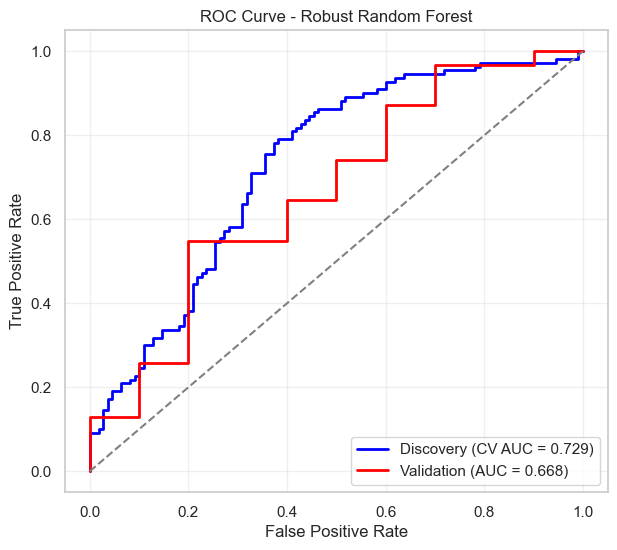


--- [RANDOM FOREST: VALIDATION REPORT @ threshold=0.5] ---
              precision    recall  f1-score   support

         0.0     0.3125    0.5000    0.3846        10
         1.0     0.8000    0.6452    0.7143        31

    accuracy                         0.6098        41
   macro avg     0.5563    0.5726    0.5495        41
weighted avg     0.6811    0.6098    0.6339        41



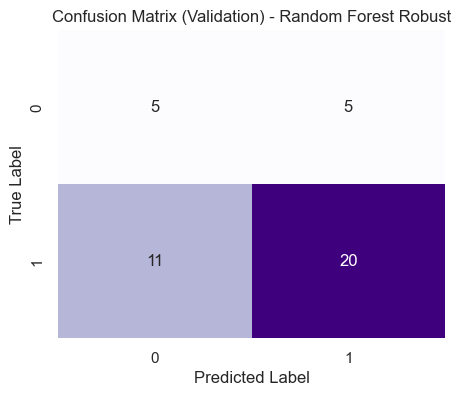

In [6]:
# =================================================================
# PHỤ LỤC: RANDOM FOREST - VERSION 2 (FULL ROBUST EVALUATION)
# - Mục tiêu: Thu hẹp khoảng cách Train-Test AUC
# - Đầy đủ: ROC Plot, Confusion Matrix Heatmap, Classification Report
# =================================================================
# region RF_Robust_Full
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

print("\n--- [RANDOM FOREST: TUNING FOR STABILITY & EVALUATION] ---")

# 1. Lưới tham số tập trung vào tính tổng quát (Hạn chế tối đa Overfitting)
rf_param_grid_robust = {
    "n_estimators": [500],
    "max_depth": [4, 6, 8],              
    "min_samples_split": [15, 20],       
    "min_samples_leaf": [5, 10],         
    "max_features": [0.3, "sqrt"]
}

cv_strategy_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Thiết lập và Huấn luyện
rf_grid_search_robust = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight="balanced", 
        n_jobs=-1,
    ),
    rf_param_grid_robust,
    cv=cv_strategy_rf,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

rf_grid_search_robust.fit(X_train_scaled, y_train)
rf_best_model = rf_grid_search_robust.best_estimator_

# 3. Tính toán xác suất dự đoán (Probabilities)
# AUC train (Out-of-fold CV)
rf_y_prob_train_cv = cross_val_predict(
    rf_best_model, X_train_scaled, y_train, 
    cv=cv_strategy_rf, method="predict_proba"
)[:, 1]

# AUC validation (Independent Test)
rf_y_prob_test = rf_best_model.predict_proba(X_test_scaled)[:, 1]

# 4. Tính toán các chỉ số ROC
rf_auc_train_cv = roc_auc_score(y_train, rf_y_prob_train_cv)
rf_fpr_train, rf_tpr_train, _ = roc_curve(y_train, rf_y_prob_train_cv)

rf_auc_test = roc_auc_score(y_test, rf_y_prob_test)
rf_fpr_test, rf_tpr_test, _ = roc_curve(y_test, rf_y_prob_test)

# 5. IN KẾT QUẢ TỔNG HỢP
print("\n" + "=" * 60)
print("KẾT QUẢ AUC (Random Forest Robust):")
print(f"- Best params: {rf_grid_search_robust.best_params_}")
print(f"- Discovery (CV) AUC: {rf_auc_train_cv:.4f}")
print(f"- Validation AUC:     {rf_auc_test:.4f}")
print(f"- Gap (Train-Test):   {abs(rf_auc_train_cv - rf_auc_test):.4f}")
print("=" * 60)

# 6. VẼ BIỂU ĐỒ ROC
plt.figure(figsize=(7, 6))
plt.plot(rf_fpr_train, rf_tpr_train, label=f"Discovery (CV AUC = {rf_auc_train_cv:.3f})", color="blue", lw=2)
plt.plot(rf_fpr_test, rf_tpr_test, label=f"Validation (AUC = {rf_auc_test:.3f})", color="red", lw=2)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.title("ROC Curve - Robust Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 7. PHÂN TÍCH CONFUSION MATRIX + CLASSIFICATION REPORT
# Sử dụng ngưỡng mặc định 0.5
rf_y_pred_test = (rf_y_prob_test >= 0.5).astype(int)

print("\n--- [RANDOM FOREST: VALIDATION REPORT @ threshold=0.5] ---")
print(classification_report(y_test, rf_y_pred_test, digits=4))

# Vẽ Heatmap cho Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title("Confusion Matrix (Validation) - Random Forest Robust")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
# endregion


--- [THÔNG TIN DỮ LIỆU] ---
- Số mẫu Negative (0): 110
- Số mẫu Positive (1): 110
- Tỉ lệ trọng số khuyến nghị: 1.00

--- [XGBOOST: TUNING MODEL - VERSION 2] ---
Fitting 5 folds for each of 48 candidates, totalling 240 fits

KẾT QUẢ AUC (XGBoost Version 2):
- Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.01, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.7}
- Discovery (5-Fold CV) AUC: 0.6957
- Validation AUC:             0.7065


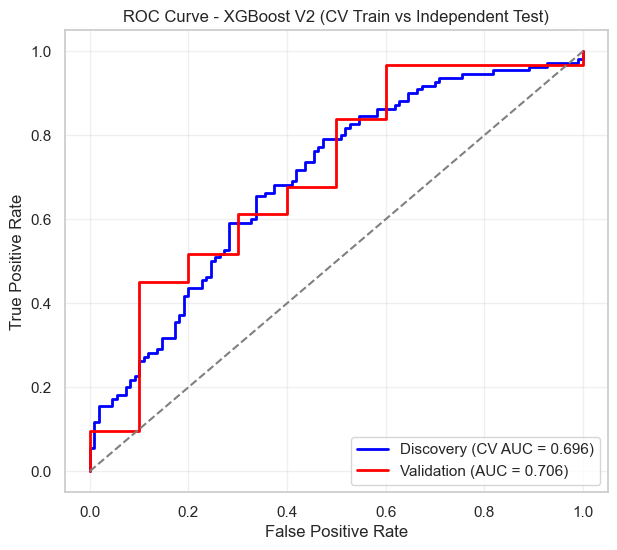


--- [XGBOOST: VALIDATION REPORT @ threshold=0.5] ---
              precision    recall  f1-score   support

           0     0.3333    0.5000    0.4000        10
           1     0.8077    0.6774    0.7368        31

    accuracy                         0.6341        41
   macro avg     0.5705    0.5887    0.5684        41
weighted avg     0.6920    0.6341    0.6547        41



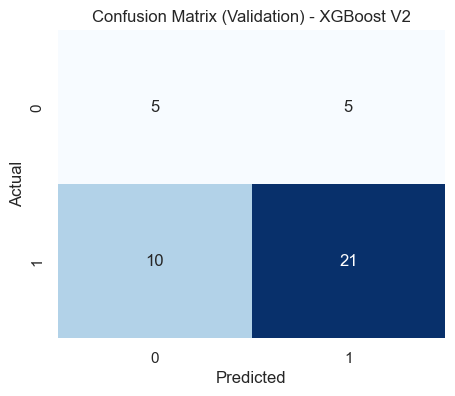

In [ ]:
# =================================================================
# PHỤ LỤC: THỬ NGHIỆM XGBOOST - VERSION 2 (FULL EVALUATION)
# - Tuning chuyên sâu: Giảm Learning Rate, tăng Estimators
# - Xử lý mất cân bằng lớp (scale_pos_weight)
# - Đánh giá chi tiết: ROC, Confusion Matrix, Classification Report
# =================================================================
# region XGBoost_V2_Full
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError("Chưa cài xgboost. Cài bằng: pip install xgboost") from e

# 1. Chuẩn bị dữ liệu (Numpy array)
X_train_xgb = np.asarray(X_train_scaled)
y_train_xgb = np.asarray(y_train).astype(int).ravel()
X_test_xgb = np.asarray(X_test_scaled)
y_test_xgb = np.asarray(y_test).astype(int).ravel()

# 2. Tự động tính scale_pos_weight (Xử lý dữ liệu lệch)
num_neg = np.sum(y_train_xgb == 0)
num_pos = np.sum(y_train_xgb == 1)
ratio = num_neg / num_pos if num_pos > 0 else 1

print(f"\n--- [THÔNG TIN DỮ LIỆU] ---")
print(f"- Số mẫu Negative (0): {num_neg}")
print(f"- Số mẫu Positive (1): {num_pos}")
print(f"- Tỉ lệ trọng số khuyến nghị: {ratio:.2f}")

# 3. Cấu hình mô hình và Lưới tham số Version 2
print("\n--- [XGBOOST: TUNING MODEL - VERSION 2] ---")
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    scale_pos_weight=ratio
)

# Lưới tham số tối ưu (48 tổ hợp)
xgb_param_grid = {
    "n_estimators": [500],
    "max_depth": [3, 5, 8],
    "learning_rate": [0.01, 0.05],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "min_child_weight": [1, 10],
}

cv_strategy_v2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Tìm kiếm tham số tốt nhất
xgb_grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=cv_strategy_v2,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train_xgb, y_train_xgb)
xgb_best_model = xgb_grid_search.best_estimator_

# 5. Tính toán xác suất dự đoán (Probabilities)
# AUC train (CV-adjusted)
xgb_y_prob_train_cv = cross_val_predict(
    xgb_best_model, X_train_xgb, y_train_xgb, 
    cv=cv_strategy_v2, method="predict_proba"
)[:, 1]

# AUC validation (Independent)
xgb_y_prob_test = xgb_best_model.predict_proba(X_test_xgb)[:, 1]

# 6. Tính toán các chỉ số ROC
xgb_auc_train_cv = roc_auc_score(y_train_xgb, xgb_y_prob_train_cv)
xgb_fpr_train, xgb_tpr_train, _ = roc_curve(y_train_xgb, xgb_y_prob_train_cv)

xgb_auc_test = roc_auc_score(y_test_xgb, xgb_y_prob_test)
xgb_fpr_test, xgb_tpr_test, _ = roc_curve(y_test_xgb, xgb_y_prob_test)

# 7. IN KẾT QUẢ TỔNG HỢP (Như code gốc)
print("\n" + "=" * 60)
print("KẾT QUẢ AUC (XGBoost Version 2):")
print(f"- Best params: {xgb_grid_search.best_params_}")
print(f"- Discovery (5-Fold CV) AUC: {xgb_auc_train_cv:.4f}")
print(f"- Validation AUC:             {xgb_auc_test:.4f}")
print("=" * 60)

# 8. Vẽ biểu đồ ROC plot
plt.figure(figsize=(7, 6))
plt.plot(xgb_fpr_train, xgb_tpr_train, label=f"Discovery (CV AUC = {xgb_auc_train_cv:.3f})", color="blue", lw=2)
plt.plot(xgb_fpr_test, xgb_tpr_test, label=f"Validation (AUC = {xgb_auc_test:.3f})", color="red", lw=2)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.title("ROC Curve - XGBoost V2 (CV Train vs Independent Test)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 9. Confusion matrix + Classification report (Validation)
# Sử dụng ngưỡng mặc định 0.5
xgb_y_pred_test = (xgb_y_prob_test >= 0.5).astype(int)

print("\n--- [XGBOOST: VALIDATION REPORT @ threshold=0.5] ---")
print(classification_report(y_test_xgb, xgb_y_pred_test, digits=4))

# Vẽ Heatmap cho Confusion Matrix
xgb_cm = confusion_matrix(y_test_xgb, xgb_y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix (Validation) - XGBoost V2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# endregion


--- [XGBOOST: FINE-TUNING VERSION 3] ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits

KẾT QUẢ AUC - XGBOOST VERSION 3 (FINE-TUNED):
- Best params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 600, 'subsample': 0.8}
- Discovery (5-Fold CV) AUC: 0.6687
- Validation AUC:             0.7258


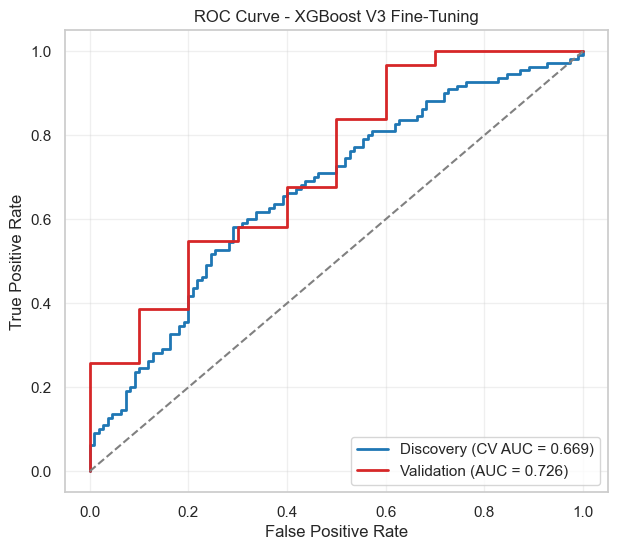


--- [XGBOOST: VALIDATION REPORT @ threshold=0.5] ---
              precision    recall  f1-score   support

           0     0.3529    0.6000    0.4444        10
           1     0.8333    0.6452    0.7273        31

    accuracy                         0.6341        41
   macro avg     0.5931    0.6226    0.5859        41
weighted avg     0.7162    0.6341    0.6583        41



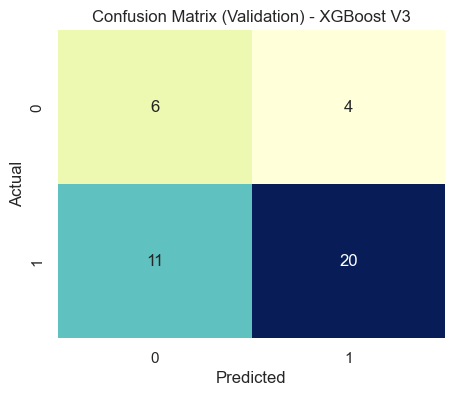

In [ ]:
# =================================================================
# PHỤ LỤC: THỬ NGHIỆM XGBOOST - VERSION 3 (FINE-TUNING)
# - Chiến lược: Thu hẹp lưới tham số quanh vùng tối ưu
# - Bổ sung Gamma: Kiểm soát phân nhánh để tăng tính tổng quát
# - Đầy đủ đánh giá: AUC, ROC, Confusion Matrix, Classification Report
# =================================================================
# region XGBoost_V3_Final
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError("Chưa cài xgboost. Cài bằng: pip install xgboost") from e

# 1. Chuẩn bị dữ liệu (Numpy array)
X_train_xgb = np.asarray(X_train_scaled)
y_train_xgb = np.asarray(y_train).astype(int).ravel()
X_test_xgb = np.asarray(X_test_scaled)
y_test_xgb = np.asarray(y_test).astype(int).ravel()

# 2. Xử lý mất cân bằng lớp
num_neg = np.sum(y_train_xgb == 0)
num_pos = np.sum(y_train_xgb == 1)
ratio = num_neg / num_pos if num_pos > 0 else 1

print(f"\n--- [XGBOOST: FINE-TUNING VERSION 3] ---")

# 3. Khởi tạo mô hình
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    scale_pos_weight=ratio
)

# 4. Lưới tham số Tinh chỉnh (Fine-tuning)
# Tập trung vào việc "mài giũa" thay vì tìm kiếm diện rộng
xgb_param_grid = {
    "n_estimators": [600],              # Tăng nhẹ số cây để học sâu hơn
    "max_depth": [4, 6],                # Giới hạn độ sâu phổ biến nhất
    "learning_rate": [0.01, 0.02, 0.03],# Học cực chậm để tránh nhảy qua điểm tối ưu
    "gamma": [0, 0.1, 0.2],             # Tham số mới: Kiểm soát điều kiện chia nhánh
    "subsample": [0.8],                 
    "colsample_bytree": [0.8],          
    "min_child_weight": [3, 5]          # Tránh các nút lá quá nhỏ gây nhiễu
}

cv_strategy_v3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Tìm kiếm tham số tốt nhất
xgb_grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=cv_strategy_v3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train_xgb, y_train_xgb)
xgb_best_model = xgb_grid_search.best_estimator_

# 6. Đánh giá AUC (Cross-Validation & Independent Validation)
xgb_y_prob_train_cv = cross_val_predict(
    xgb_best_model, X_train_xgb, y_train_xgb, 
    cv=cv_strategy_v3, method="predict_proba"
)[:, 1]

xgb_y_prob_test = xgb_best_model.predict_proba(X_test_xgb)[:, 1]

xgb_auc_train_cv = roc_auc_score(y_train_xgb, xgb_y_prob_train_cv)
xgb_fpr_train, xgb_tpr_train, _ = roc_curve(y_train_xgb, xgb_y_prob_train_cv)

xgb_auc_test = roc_auc_score(y_test_xgb, xgb_y_prob_test)
xgb_fpr_test, xgb_tpr_test, _ = roc_curve(y_test_xgb, xgb_y_prob_test)

# 7. Xuất kết quả chi tiết (Format chuẩn bộ code gốc)
print("\n" + "=" * 60)
print("KẾT QUẢ AUC - XGBOOST VERSION 3 (FINE-TUNED):")
print(f"- Best params: {xgb_grid_search.best_params_}")
print(f"- Discovery (5-Fold CV) AUC: {xgb_auc_train_cv:.4f}")
print(f"- Validation AUC:             {xgb_auc_test:.4f}")
print("=" * 60)

# 8. Vẽ biểu đồ ROC plot
plt.figure(figsize=(7, 6))
plt.plot(xgb_fpr_train, xgb_tpr_train, label=f"Discovery (CV AUC = {xgb_auc_train_cv:.3f})", color="#1f77b4", lw=2)
plt.plot(xgb_fpr_test, xgb_tpr_test, label=f"Validation (AUC = {xgb_auc_test:.3f})", color="#d62728", lw=2)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.title("ROC Curve - XGBoost V3 Fine-Tuning")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 9. Confusion matrix + Report
xgb_y_pred_test = (xgb_y_prob_test >= 0.5).astype(int)

print("\n--- [XGBOOST: VALIDATION REPORT @ threshold=0.5] ---")
print(classification_report(y_test_xgb, xgb_y_pred_test, digits=4))

xgb_cm = confusion_matrix(y_test_xgb, xgb_y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("Confusion Matrix (Validation) - XGBoost V3")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# endregion


--- [SVM: PREPARING DATA & TUNING] ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits

KẾT QUẢ AUC (Support Vector Machine):
- Best params: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
- Discovery (CV) AUC: 0.7226
- Validation AUC:     0.5677


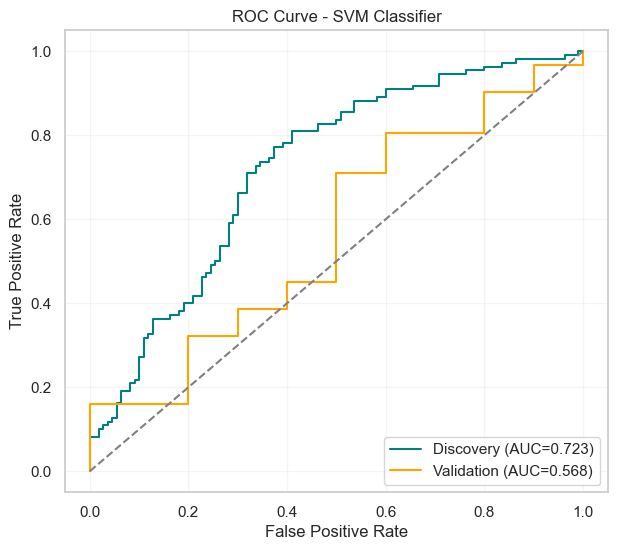


--- [SVM: VALIDATION REPORT] ---
              precision    recall  f1-score   support

           0     0.3125    0.5000    0.3846        10
           1     0.8000    0.6452    0.7143        31

    accuracy                         0.6098        41
   macro avg     0.5563    0.5726    0.5495        41
weighted avg     0.6811    0.6098    0.6339        41



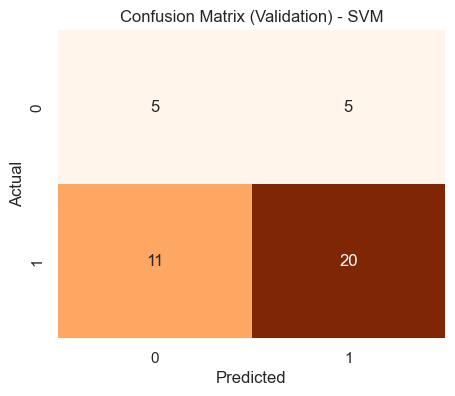

In [5]:
# =================================================================
# PHỤ LỤC: THỬ NGHIỆM SUPPORT VECTOR MACHINE (SVM)
# - Tuning bằng 5-Fold Stratified CV
# - Sử dụng Kernel RBF (phi tuyến tính) để bắt các mối quan hệ phức tạp
# - Đầy đủ: ROC Plot, Confusion Matrix, Classification Report
# =================================================================
# region SVM_Independent
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

print("\n--- [SVM: PREPARING DATA & TUNING] ---")

# 1. Đảm bảo dữ liệu tồn tại và được chuẩn hóa (Scaling)
# SVM bắt buộc phải scale dữ liệu để hoạt động chính xác
if "X_train" in globals() and "y_train" in globals():
    scaler = StandardScaler()
    X_train_final = scaler.fit_transform(X_train)
    X_test_final = scaler.transform(X_test)
    y_train_final = np.asarray(y_train).astype(int).ravel()
    y_test_final = np.asarray(y_test).astype(int).ravel()
elif "X_train_scaled" in globals():
    X_train_final = X_train_scaled
    X_test_final = X_test_scaled
    y_train_final = np.asarray(y_train).astype(int).ravel()
    y_test_final = np.asarray(y_test).astype(int).ravel()
else:
    raise NameError("Không tìm thấy X_train hoặc X_train_scaled. Hãy chạy bước nạp dữ liệu trước.")

# 2. Lưới tham số cho SVM
# C: Tham số điều chuẩn (Regularization)
# gamma: Định nghĩa tầm ảnh hưởng của một điểm dữ liệu đơn lẻ
svm_param_grid = {
    "C": [0.1, 1, 10], 
    "gamma": ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf"] # Kernel phổ biến nhất cho dữ liệu y sinh
}

cv_strategy_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Thiết lập GridSearchCV
# probability=True là bắt buộc để vẽ được đường cong ROC và tính AUC
svm_grid_search = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight="balanced"),
    svm_param_grid,
    cv=cv_strategy_svm,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# 4. Huấn luyện
svm_grid_search.fit(X_train_final, y_train_final)
svm_best_model = svm_grid_search.best_estimator_

# 5. Tính toán xác suất dự đoán
svm_y_prob_train_cv = cross_val_predict(
    svm_best_model, X_train_final, y_train_final, 
    cv=cv_strategy_svm, method="predict_proba"
)[:, 1]

svm_y_prob_test = svm_best_model.predict_proba(X_test_final)[:, 1]

# 6. Chỉ số ROC & AUC
svm_auc_train_cv = roc_auc_score(y_train_final, svm_y_prob_train_cv)
svm_auc_test = roc_auc_score(y_test_final, svm_y_prob_test)
svm_fpr_train, svm_tpr_train, _ = roc_curve(y_train_final, svm_y_prob_train_cv)
svm_fpr_test, svm_tpr_test, _ = roc_curve(y_test_final, svm_y_prob_test)

# 7. In kết quả tổng hợp
print("\n" + "=" * 60)
print("KẾT QUẢ AUC (Support Vector Machine):")
print(f"- Best params: {svm_grid_search.best_params_}")
print(f"- Discovery (CV) AUC: {svm_auc_train_cv:.4f}")
print(f"- Validation AUC:     {svm_auc_test:.4f}")
print("=" * 60)

# 8. Vẽ biểu đồ ROC
plt.figure(figsize=(7, 6))
plt.plot(svm_fpr_train, svm_tpr_train, label=f"Discovery (AUC={svm_auc_train_cv:.3f})", color="teal")
plt.plot(svm_fpr_test, svm_tpr_test, label=f"Validation (AUC={svm_auc_test:.3f})", color="orange")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.title("ROC Curve - SVM Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

# 9. Confusion matrix + Report
svm_y_pred_test = svm_best_model.predict(X_test_final)
print("\n--- [SVM: VALIDATION REPORT] ---")
print(classification_report(y_test_final, svm_y_pred_test, digits=4))

svm_cm = confusion_matrix(y_test_final, svm_y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Oranges", cbar=False)
plt.title("Confusion Matrix (Validation) - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# endregion

In [ ]:
# =================================================================
# PHỤ LỤC: SVM - VERSION 3 (RE-BALANCING MODEL)
# - Mục tiêu: Đưa AUC vượt lên trên mức 0.5 và hướng tới 0.7
# - Chiến lược: Tăng nhẹ C và Gamma để thoát khỏi Underfitting
# =================================================================
# region SVM_V3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC 
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

print("\n--- [SVM: TUNING VERSION 3 - RE-BALANCING] ---")

# 1. Đảm bảo dữ liệu đầu vào
if 'X_train_final' not in globals():
    raise NameError("Hãy chạy lại khối code trước để chuẩn bị dữ liệu (X_train_final).")

# 2. Lưới tham số Version 3: Tìm điểm cân bằng
# Chúng ta đưa C về vùng trung lập (không quá thấp, không quá cao)
svm_param_grid_v3 = {
    "C": [0.1, 0.5, 1.0, 2.0],         
    "gamma": ["scale", 0.001, 0.01],    
    "kernel": ["rbf"]
}

cv_strategy_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Thiết lập GridSearchCV
svm_grid_search_v3 = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight="balanced"),
    svm_param_grid_v3,
    cv=cv_strategy_svm,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# 4. Huấn luyện
svm_grid_search_v3.fit(X_train_final, y_train_final)
svm_best_model_v3 = svm_grid_search_v3.best_estimator_

# 5. Đánh giá AUC
svm_y_prob_train_cv = cross_val_predict(
    svm_best_model_v3, X_train_final, y_train_final, 
    cv=cv_strategy_svm, method="predict_proba"
)[:, 1]

svm_y_prob_test = svm_best_model_v3.predict_proba(X_test_final)[:, 1]

svm_auc_train_cv = roc_auc_score(y_train_final, svm_y_prob_train_cv)
svm_auc_test = roc_auc_score(y_test_final, svm_y_prob_test)

# 6. In kết quả tổng hợp
print("\n" + "=" * 60)
print("KẾT QUẢ AUC (SVM VERSION 3):")
print(f"- Best params: {svm_grid_search_v3.best_params_}")
print(f"- Discovery (CV) AUC: {svm_auc_train_cv:.4f}")
print(f"- Validation AUC:     {svm_auc_test:.4f}")
print("=" * 60)

# 7. Vẽ biểu đồ ROC
svm_fpr_train, svm_tpr_train, _ = roc_curve(y_train_final, svm_y_prob_train_cv)
svm_fpr_test, svm_tpr_test, _ = roc_curve(y_test_final, svm_y_prob_test)

plt.figure(figsize=(7, 6))
plt.plot(svm_fpr_train, svm_tpr_train, label=f"Discovery (AUC={svm_auc_train_cv:.3f})", color="teal", lw=2)
plt.plot(svm_fpr_test, svm_tpr_test, label=f"Validation (AUC={svm_auc_test:.3f})", color="orange", lw=2)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.title("ROC Curve - SVM Version 3")
plt.legend(loc="lower right")
plt.show()

# 8. Confusion matrix
svm_y_pred_test = svm_best_model_v3.predict(X_test_final)
svm_cm = confusion_matrix(y_test_final, svm_y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("Confusion Matrix - SVM V3")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# endregion